In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random
import os


In [97]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
train_data_dir = "data/Training"
test_data_dir = "data/Validation"

In [99]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# training dataset loader
train_dataset = datasets.ImageFolder(
    train_data_dir,
    transform=train_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# validation dataset loader
val_dataset = datasets.ImageFolder(
    test_data_dir,
    transform=val_transform
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [100]:
print(train_dataset)


Dataset ImageFolder
    Number of datapoints: 47009
    Root location: /content/data/Training
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
           )


In [101]:
from collections import Counter

class_counts = Counter(train_dataset.targets)
print(class_counts)

Counter({1: 23766, 0: 23243})


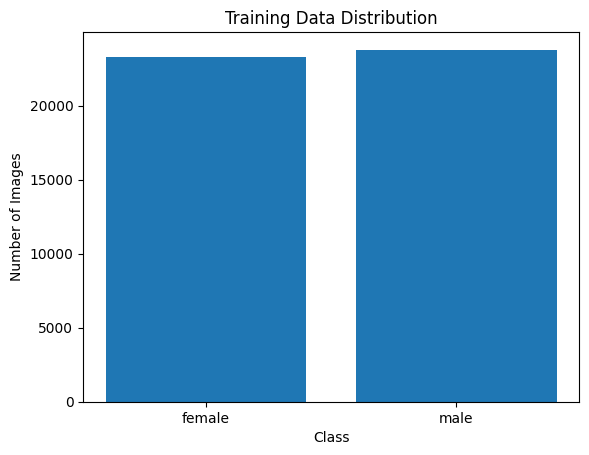

In [102]:
classes = train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.show()


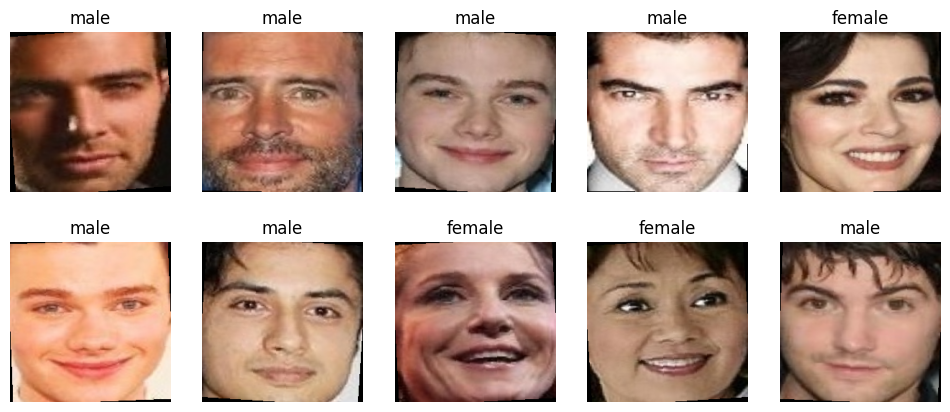

In [103]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

indices = random.sample(range(len(train_dataset)), 10)

for ax, idx in zip(axes.flatten(), indices):
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.show()


In [104]:
class Gender(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [105]:
model = Gender().to(device)

In [106]:
print(model)


Gender(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [107]:

loss_fun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


In [108]:
epochs=15

for epoch in range(epochs):
    model.train()
    running_loss=0
    for images ,labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=loss_fun(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch+1}:loss={running_loss/len(train_loader):.4f}")



epoch 1:loss=0.6486
epoch 2:loss=0.5646
epoch 3:loss=0.5034
epoch 4:loss=0.4294
epoch 5:loss=0.3921
epoch 6:loss=0.3592
epoch 7:loss=0.3327
epoch 8:loss=0.3062
epoch 9:loss=0.2957
epoch 10:loss=0.2779
epoch 11:loss=0.2672
epoch 12:loss=0.2566
epoch 13:loss=0.2397
epoch 14:loss=0.2351
epoch 15:loss=0.2252


In [109]:
model.eval()
correct,total=0,0
val_loss=0

with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        loss=loss_fun(outputs,labels)
        val_loss += loss.item()
        _,predicted=torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {100*correct/total:.2f}%")

Val Loss: 0.2012, Val Accuracy: 91.87%


In [110]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=classes))

[[5262  576]
 [ 371 5437]]
              precision    recall  f1-score   support

      female       0.93      0.90      0.92      5838
        male       0.90      0.94      0.92      5808

    accuracy                           0.92     11646
   macro avg       0.92      0.92      0.92     11646
weighted avg       0.92      0.92      0.92     11646



In [112]:
torch.save(model.state_dict(), "gender_model.pth")
